# Evaluate Ensemble

B Steele, Colorado State University, ROSSyndicate — last updated Sep 17, 2026

This notebook assembles the production 10-seed XGBoost ensemble trained in `04_make_models.ipynb`, evaluates it on the fixed holdout built in `03_split_data.ipynb`, and validates its feature attributions with SHAP.

This replaces an earlier 5-seed x 2-algorithm (XGBoost + LightGBM) design. A variance decomposition of that ensemble's holdout predictions found seed choice accounted for roughly 65% of the ensemble's internal prediction spread, versus roughly 13% for model architecture — the two algorithms agreed closely with each other (0.998 correlation) while different seeds disagreed with each other substantially more (~0.99 pairwise correlation). Given seed, not algorithm, was the dominant source of useful ensemble variability, the production ensemble was rebuilt as a single algorithm (XGBoost) over 10 seeds instead, at the same total model count (40) and no measurable accuracy cost.</cell id="71a56d63">


## Setup

In [1]:
import json
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb

sys.path.insert(0, str(Path("python").resolve()))
import features
import metrics as M
import model_xgb
import spatial_cv

AQUAMATCH_DIR = Path("aquamatch_files")
MODELS_DIR = Path("xg_models") / "v3_production"
TARGET = "harmonized_value"
MOD = model_xgb
SEEDS = list(range(601, 611))

ROSS_LT_PAL = ["#002EA3", "#E70870", "#256BF5", "#745CFB", "#1E4D2B", "#56104E"]

df = pd.read_parquet(AQUAMATCH_DIR / "base_with_splits.parquet")
df = features.add_spectral_indices(df)
df = features.coarsen_site_features(df)
df = spatial_cv.build_splits(df, ensemble_seeds=SEEDS)
holdout = df[df["is_holdout"]].reset_index(drop=True)
print(f"holdout: {len(holdout):,} rows")

/Users/steeleb/miniconda3/envs/regional_clarity/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


holdout: 2,334 rows


## Assemble the ensemble

Each seed independently selected its own features and hyperparameters and produced holdout predictions from its own 4 fold models. The production prediction for a given (site, date) is the plain average across all 10 seeds x 4 folds — 40 models — with no per-seed weighting.

In [2]:
all_rows = []
for seed in SEEDS:
    all_rows.append(pd.read_parquet(MODELS_DIR / f"seed{seed}" / "holdout_predictions.parquet"))
all_preds = pd.concat(all_rows, ignore_index=True)

ensemble_pred = all_preds.groupby(["siteSR_id", "date"]).agg(
    y=("y", "first"), pred=("pred", "mean"), HUC4=("HUC4", "first"), HUC8=("HUC8", "first")).reset_index()
ensemble_metrics = M.all_metrics(ensemble_pred["y"], ensemble_pred["pred"])
print(f"production ensemble (10 seeds x xgboost, 40 models): {ensemble_metrics}")

production ensemble (10 seeds x xgboost, 40 models): {'rmse': 1.8466498435492145, 'mae': 1.3469278292199338, 'mape': 0.6974475150947105, 'bias': 0.21648619859614288, 'p_bias': 5.404338563371457, 'smape': 0.38109833864420484, 'r2': 0.5075473903548398, 'n': 2133}


## Predicted vs. observed

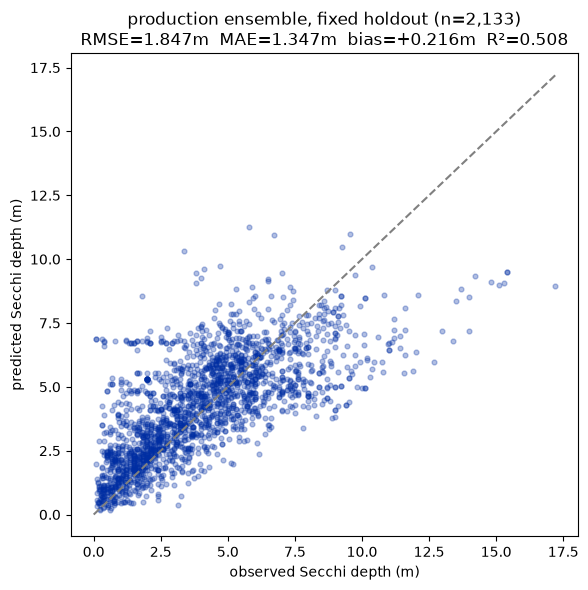

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(ensemble_pred["y"], ensemble_pred["pred"], alpha=0.3, s=12, color=ROSS_LT_PAL[0])
lims = [0, max(ensemble_pred["y"].max(), ensemble_pred["pred"].max())]
ax.plot(lims, lims, ls="--", color="grey")
ax.set_xlabel("observed Secchi depth (m)")
ax.set_ylabel("predicted Secchi depth (m)")
ax.set_title(f"production ensemble, fixed holdout (n={len(ensemble_pred):,})\n"
             f"RMSE={ensemble_metrics['rmse']:.3f}m  MAE={ensemble_metrics['mae']:.3f}m  "
             f"bias={ensemble_metrics['bias']:+.3f}m  R²={ensemble_metrics['r2']:.3f}")
plt.tight_layout()
plt.show()

## Performance by HUC8

Reported at the HUC8 level, the split's actual unit (see `03_split_data.ipynb`), rather than aggregated up to HUC4 — a HUC4 can straddle both the holdout and multiple CV folds, but every HUC8 sits entirely on one side. There is no HUC8 boundary-polygon layer on hand, so rather than a choropleth, each holdout site is plotted individually, colored by its own HUC8 group's error, with HUC4 boundaries drawn only as spatial context. Basin-level difficulty in this dataset has consistently traced back to physical causes (training-envelope extrapolation, genuinely low optical signal) documented in the earlier outlier-HUC investigation, not to data quality problems that would call for dropping anything.

In [4]:
huc8_metrics = (ensemble_pred.groupby("HUC8")
                .apply(lambda g: pd.Series({**M.all_metrics(g["y"], g["pred"]), "HUC4": g["HUC4"].iloc[0]}),
                       include_groups=False)
                .reset_index()
                .sort_values("rmse", ascending=False))
huc8_metrics

/Users/steeleb/miniconda3/envs/regional_clarity/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Users/steeleb/miniconda3/envs/regional_clarity/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Users/steeleb/miniconda3/envs/regional_clarity/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,HUC8,rmse,mae,mape,bias,p_bias,smape,r2,n,HUC4
18,14070006,3.292907,2.773790,2.083551,1.156731,26.182090,0.633630,0.322321,243,1407
22,17010210,2.575597,1.954624,0.319404,-0.450348,-6.637717,0.292602,0.039285,124,1701
6,10180002,2.416638,1.866586,0.518114,1.866586,49.492816,0.375283,0.057899,7,1018
25,17010303,2.296900,1.725177,0.279903,-1.193418,-20.538408,0.304952,0.425024,165,1701
23,17010213,1.913470,1.673624,0.658328,1.673624,45.652595,0.413416,0.259847,5,1701
27,17040103,1.802769,1.501212,0.218048,-1.501212,-24.115851,0.254522,1.000000,2,1704
20,16020310,1.679697,1.447365,1.931730,1.055352,64.626076,0.776858,0.278390,156,1602
16,14040107,1.614981,1.287746,0.520112,-0.215713,-6.489407,0.432847,0.229272,54,1404
30,17050123,1.609691,1.241088,0.438237,0.105877,2.613779,0.334141,0.516833,210,1705
24,17010216,1.495561,1.495561,1.699501,1.495561,169.950059,0.918773,NaN,1,1701


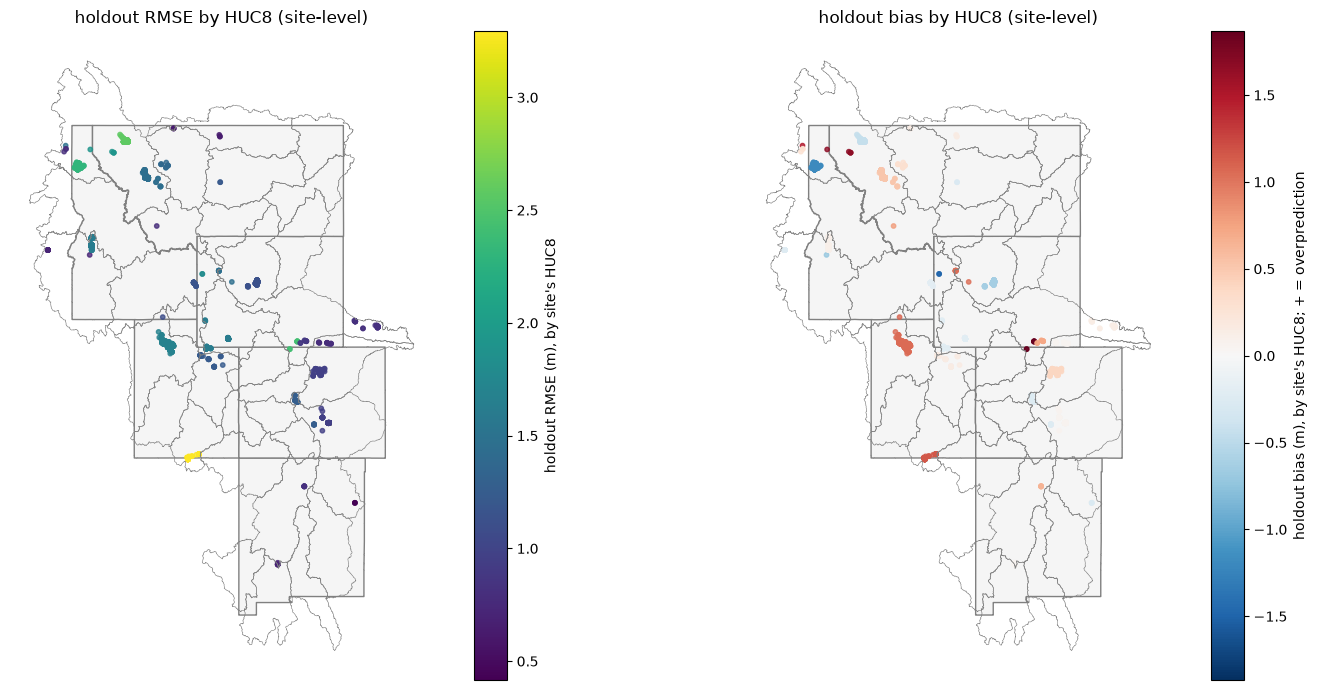

In [5]:
states = gpd.read_file(AQUAMATCH_DIR / "states.gdb", layer="states")
huc4s = gpd.read_file(AQUAMATCH_DIR / "huc4_filtered.gdb", layer="huc4_filtered")

latlon_lookup = df[["siteSR_id", "date", "lat", "lon"]].drop_duplicates(subset=["siteSR_id", "date"])
site_metrics = (ensemble_pred.merge(latlon_lookup, on=["siteSR_id", "date"], how="left")
                .merge(huc8_metrics[["HUC8", "rmse", "bias"]], on="HUC8", how="left"))
site_gdf = gpd.GeoDataFrame(site_metrics, geometry=gpd.points_from_xy(site_metrics.lon, site_metrics.lat),
                            crs="EPSG:4326").to_crs(huc4s.crs)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
states.plot(ax=ax, color="whitesmoke", edgecolor="grey")
huc4s.boundary.plot(ax=ax, color="grey", linewidth=0.4)
site_gdf.plot(ax=ax, column="rmse", cmap="viridis", legend=True, markersize=10, alpha=0.8,
              legend_kwds={"label": "holdout RMSE (m), by site's HUC8"})
ax.set_title("holdout RMSE by HUC8 (site-level)")
ax.set_axis_off()

ax = axes[1]
states.plot(ax=ax, color="whitesmoke", edgecolor="grey")
huc4s.boundary.plot(ax=ax, color="grey", linewidth=0.4)
vmax = site_gdf["bias"].abs().max()
site_gdf.plot(ax=ax, column="bias", cmap="RdBu_r", vmin=-vmax, vmax=vmax, legend=True, markersize=10, alpha=0.8,
              legend_kwds={"label": "holdout bias (m), by site's HUC8; + = overprediction"})
ax.set_title("holdout bias by HUC8 (site-level)")
ax.set_axis_off()

fig.tight_layout()
plt.show()

### Predicted vs. observed in the worst-performing HUC8s

Small multiples for the worst-RMSE HUC8s (restricted to `n >= 15` so this isn't dominated by tiny, noisy groups), each panel on its own 1:1 line.

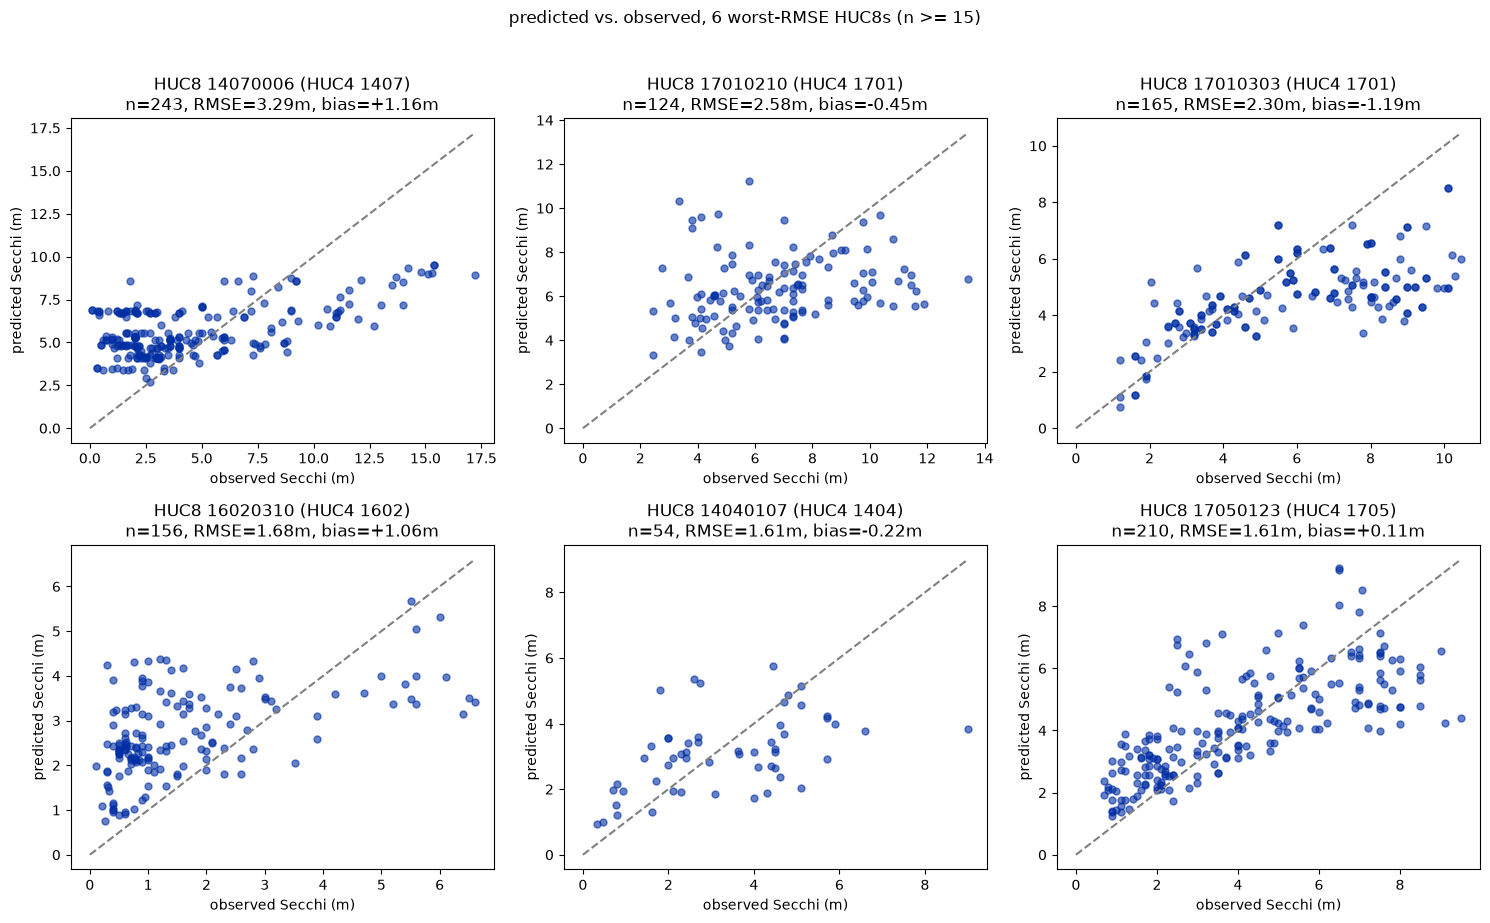

In [6]:
N_WORST = 6
MIN_N = 15
worst_huc8 = huc8_metrics[huc8_metrics["n"] >= MIN_N].sort_values("rmse", ascending=False).head(N_WORST)

n_panels = len(worst_huc8)
ncols = 3
nrows = -(-n_panels // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)

for ax, (_, row) in zip(axes.flat, worst_huc8.iterrows()):
    sub = ensemble_pred[ensemble_pred["HUC8"] == row["HUC8"]]
    ax.scatter(sub["y"], sub["pred"], alpha=0.6, s=25, color=ROSS_LT_PAL[0])
    lims = [0, max(sub["y"].max(), sub["pred"].max())]
    ax.plot(lims, lims, ls="--", color="grey")
    ax.set_title(f"HUC8 {row['HUC8']} (HUC4 {row['HUC4']})\n"
                 f"n={int(row['n'])}, RMSE={row['rmse']:.2f}m, bias={row['bias']:+.2f}m")
    ax.set_xlabel("observed Secchi (m)")
    ax.set_ylabel("predicted Secchi (m)")

for ax in axes.flat[n_panels:]:
    ax.set_visible(False)

fig.suptitle(f"predicted vs. observed, {N_WORST} worst-RMSE HUC8s (n >= {MIN_N})", y=1.02)
fig.tight_layout()
plt.show()

## Seed-to-seed spread

With a single algorithm, all spread across the 10 ensemble members is seed-driven by construction — this quantifies how much of it there is (for context, the earlier 5-seed x 2-algorithm design decomposed its own spread as ~65% seed-driven, ~13% architecture-driven, which motivated moving to this single-algorithm, more-seeds design in the first place).

typical per-point std across the 10 seeds: 0.1583m (median 0.1375m)
seed-vs-seed pairwise corr: mean=0.9933, min=0.9859, max=0.9978


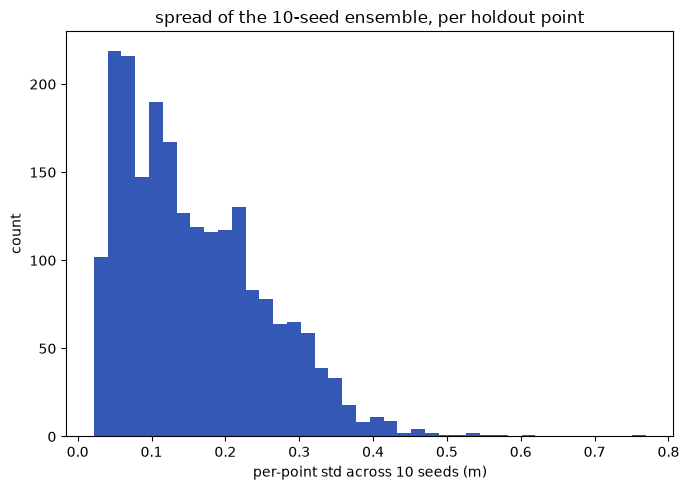

In [7]:
pivot = all_preds.pivot_table(index=["siteSR_id", "date"], columns="seed", values="pred")
per_point_std = pivot.std(axis=1)
print(f"typical per-point std across the 10 seeds: {per_point_std.mean():.4f}m "
      f"(median {per_point_std.median():.4f}m)")

seed_corrs = []
for i, s1 in enumerate(pivot.columns):
    for s2 in pivot.columns[i + 1:]:
        seed_corrs.append(np.corrcoef(pivot[s1], pivot[s2])[0, 1])
print(f"seed-vs-seed pairwise corr: mean={np.mean(seed_corrs):.4f}, "
      f"min={np.min(seed_corrs):.4f}, max={np.max(seed_corrs):.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(per_point_std, bins=40, color=ROSS_LT_PAL[0], alpha=0.8)
ax.set_xlabel("per-point std across 10 seeds (m)")
ax.set_ylabel("count")
ax.set_title("spread of the 10-seed ensemble, per holdout point")
plt.tight_layout()
plt.show()

## SHAP feature attribution

Each seed selects its own final feature set independently (backward elimination converges to a different set per seed). Cross-seed attribution comparisons are restricted to the **unanimous core** — features present in every seed's own final set. Each seed's own final feature set and gap-aware-tuned hyperparameters are reused unchanged (no re-selection/re-tuning), retrained on that seed's 4 folds, and explained with `shap.TreeExplainer` on the shared holdout.

In [8]:
def load_seed_config(seed):
    with open(MODELS_DIR / f"seed{seed}" / "backward_elim_summary.json") as fh:
        feats = json.load(fh)["final_features"]
    with open(MODELS_DIR / f"seed{seed}" / "final_tune_xgboost.json") as fh:
        params = json.load(fh)["best_params"]
    return feats, params


per_seed = {}
for seed in SEEDS:
    folds = spatial_cv.build_folds(df, seed)
    feats, params = load_seed_config(seed)
    print(f"seed{seed}: training 4 folds + SHAP on {len(holdout)}-row holdout ({len(feats)} feats)")
    fold_shaps = []
    for f in folds:
        model = MOD.train_fold_models([f], feats, TARGET, params)[0]
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(xgb.DMatrix(holdout[feats]))
        fold_shaps.append(np.asarray(sv))
    mean_shap = np.mean(fold_shaps, axis=0)
    per_seed[seed] = pd.DataFrame(mean_shap, columns=feats)

unanimous = None
for feats_df in per_seed.values():
    cols = set(feats_df.columns)
    unanimous = cols if unanimous is None else (unanimous & cols)
unanimous = sorted(unanimous)
print(f"\nunanimous core ({len(unanimous)} features): {unanimous}")

seed601: training 4 folds + SHAP on 2334-row holdout (34 feats)


seed602: training 4 folds + SHAP on 2334-row holdout (25 feats)


seed603: training 4 folds + SHAP on 2334-row holdout (26 feats)


seed604: training 4 folds + SHAP on 2334-row holdout (25 feats)


seed605: training 4 folds + SHAP on 2334-row holdout (30 feats)


...

seed607: training 4 folds + SHAP on 2334-row holdout (27 feats)


seed608: training 4 folds + SHAP on 2334-row holdout (30 feats)


seed609: training 4 folds + SHAP on 2334-row holdout (28 feats)


seed610: training 4 folds + SHAP on 2334-row holdout (32 feats)



unanimous core (20 features): ['BG', 'BR', 'MNDWI', 'NDSSI', 'NDVI', 'NDWI', 'NR', 'atm_corr_LaSRC', 'catchment_area_sqkm', 'fai', 'nir_corr7', 'pct_cropland_2006', 'pct_impervious_2006', 'pct_urban_2006', 'pct_wetland_2006', 'red_corr7', 'shore_flag', 'srad_Wm2_prev1', 'tmax_degC_prev30', 'tmean_degC_prev30']


top 8 features by mean|SHAP|:
BG                     0.5957
red_corr7              0.4660
catchment_area_sqkm    0.3398
BR                     0.2463
fai                    0.2170
MNDWI                  0.1949
NR                     0.1923
pct_urban_2006         0.1462
dtype: float32

share of total mean|SHAP| attribution by category:
optical    70.099998
site       24.400000
weather     5.500000
dtype: float32


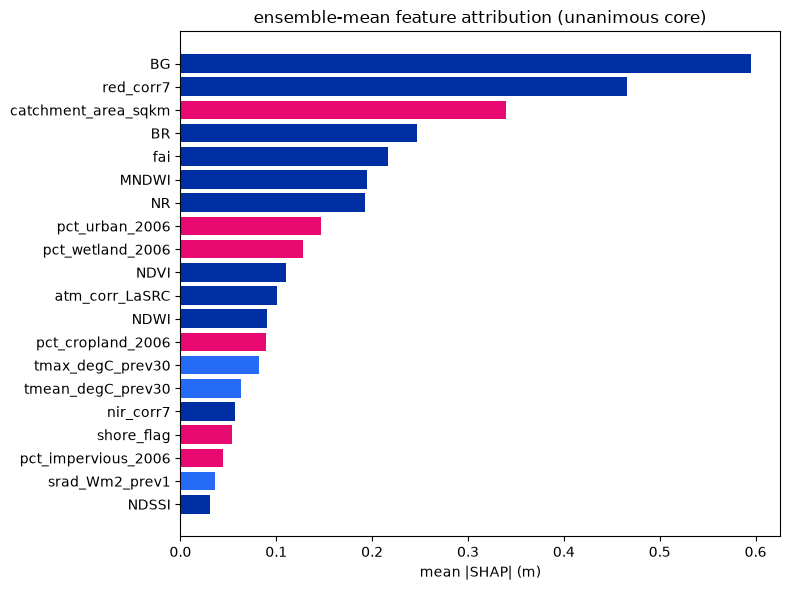

In [9]:
long_rows = []
for seed, feats_df in per_seed.items():
    sub = feats_df[unanimous].copy()
    sub["seed"] = seed
    sub["_row"] = np.arange(len(holdout))
    long_rows.append(sub)
long_df = pd.concat(long_rows, ignore_index=True)

ensemble_mean_shap = long_df.groupby("_row")[unanimous].mean().sort_index()

SITE_COLS = {"elevation_m", "catchment_area_sqkm", "pct_impervious_2006", "pct_urban_2006",
             "pct_forest_2006", "pct_cropland_2006", "pct_wetland_2006", "shore_flag"}
WEATHER_PREFIXES = ("precip_mm_prev", "tmax_degC_prev", "tmean_degC_prev", "tmin_degC_prev", "srad_Wm2_prev")


def categorize(feat):
    if feat in SITE_COLS:
        return "site"
    if feat.startswith(WEATHER_PREFIXES):
        return "weather"
    return "optical"


mean_abs_shap = ensemble_mean_shap.abs().mean().sort_values(ascending=False)
cat_share = mean_abs_shap.groupby(categorize).sum() / mean_abs_shap.sum() * 100
print("top 8 features by mean|SHAP|:")
print(mean_abs_shap.head(8).round(4))
print("\nshare of total mean|SHAP| attribution by category:")
print(cat_share.round(1))

fig, ax = plt.subplots(figsize=(8, 6))
colors = mean_abs_shap.index.map(lambda f: {"optical": ROSS_LT_PAL[0], "site": ROSS_LT_PAL[1],
                                             "weather": ROSS_LT_PAL[2]}[categorize(f)])
ax.barh(mean_abs_shap.index[::-1], mean_abs_shap.values[::-1], color=colors[::-1])
ax.set_xlabel("mean |SHAP| (m)")
ax.set_title("ensemble-mean feature attribution (unanimous core)")
plt.tight_layout()
plt.show()

## Per-HUC8 SHAP

catchment_area_sqkm mean|SHAP| by HUC8 (top 5):
HUC8
14070006    1.0979
16020310    0.8499
17040103    0.3904
17050122    0.3885
17010308    0.3481
Name: catchment_area_sqkm, dtype: float32


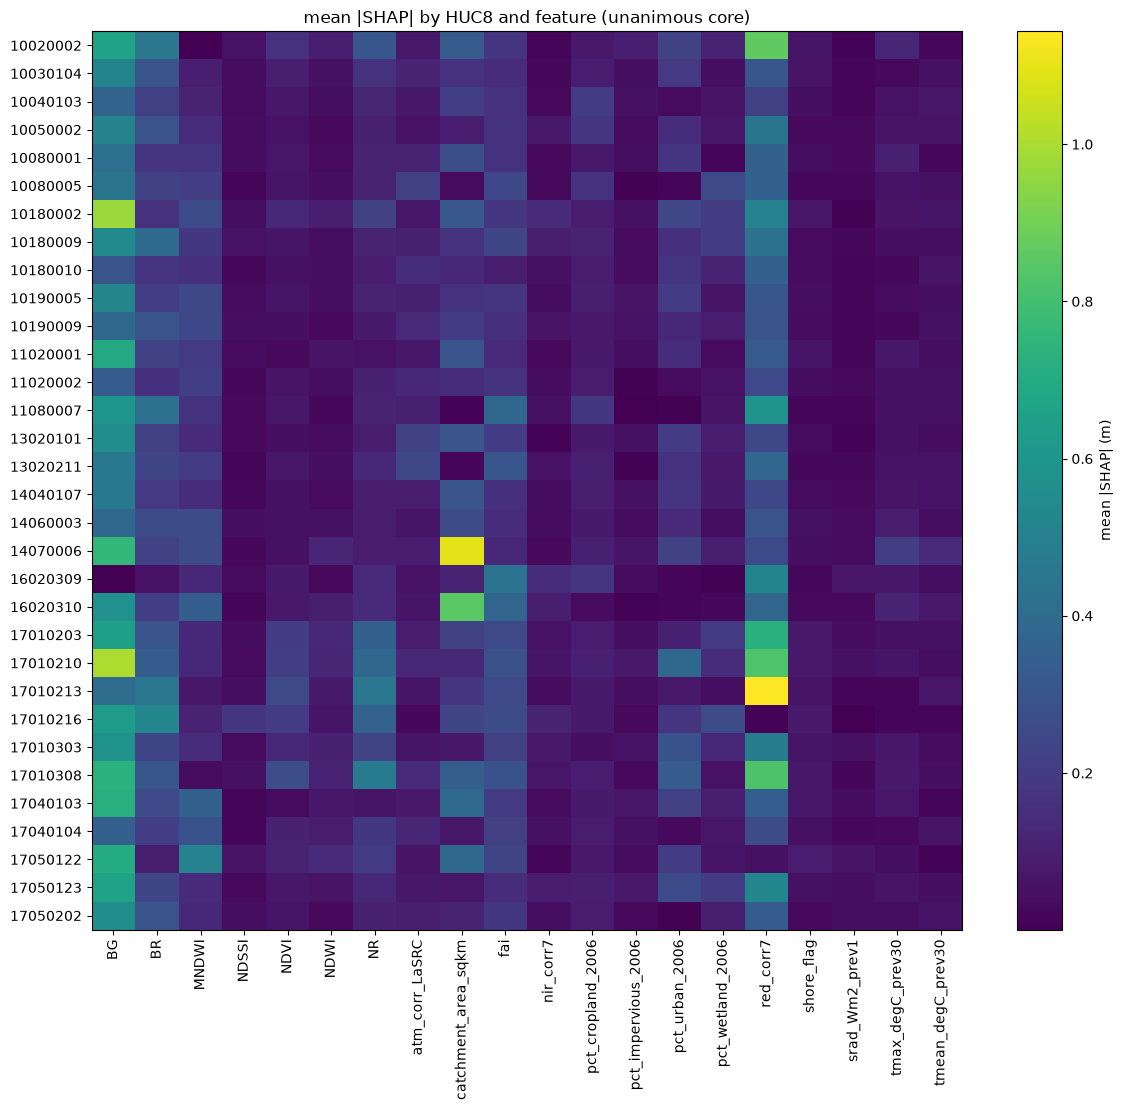

In [10]:
shap_with_huc8 = ensemble_mean_shap.copy()
shap_with_huc8["HUC8"] = holdout["HUC8"].values
huc8_shap = shap_with_huc8.groupby("HUC8")[unanimous].apply(lambda g: g.abs().mean())

if "catchment_area_sqkm" in huc8_shap.columns:
    print("catchment_area_sqkm mean|SHAP| by HUC8 (top 5):")
    print(huc8_shap["catchment_area_sqkm"].sort_values(ascending=False).head(5).round(4))

fig, ax = plt.subplots(figsize=(12, max(4, 0.35 * len(huc8_shap))))
im = ax.imshow(huc8_shap.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(unanimous)))
ax.set_xticklabels(unanimous, rotation=90)
ax.set_yticks(range(len(huc8_shap)))
ax.set_yticklabels(huc8_shap.index)
ax.set_title("mean |SHAP| by HUC8 and feature (unanimous core)")
fig.colorbar(im, ax=ax, label="mean |SHAP| (m)")
plt.tight_layout()
plt.show()

## Production summary

The production model is a 40-member ensemble — 10 independent HUC8-random CV arrangements x 4 folds each, single algorithm (XGBoost) — trained unweighted, with gap-aware hyperparameter selection at every tuning stage and per-seed feature sets chosen by correlation pruning followed by shadow-decoy backward elimination. Every member is evaluated on one fixed HUC8-random holdout that no model ever trains on. Artifacts (fold models, per-seed feature/hyperparameter configs, holdout predictions) are saved under `xg_models/v3_production/seed{601–610}/`.

This design replaced an earlier 5-seed x 2-algorithm (XGBoost + LightGBM) ensemble after a variance decomposition found seed choice accounted for roughly 65% of that ensemble's internal prediction spread versus roughly 13% for model architecture — the two algorithms agreed closely with each other while different seeds disagreed substantially more. Moving to a single algorithm over more seeds, at the same total model count, matched or marginally beat the two-algorithm design's holdout accuracy while halving the modeling code path (no LightGBM-specific tuning/elimination/serving logic to maintain).

See the cells above for holdout metrics, HUC8-level error breakdown, seed-to-seed spread, and SHAP feature attribution for this ensemble.